<a href="https://colab.research.google.com/github/wallacecarlis/data_science/blob/main/PROJETO_9_TIME_SERIES_WINE_PROPHET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

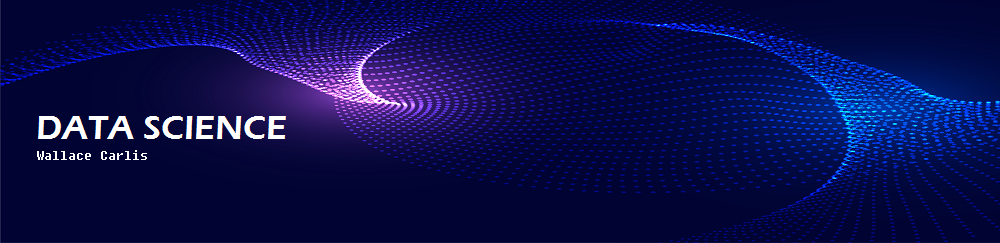

# **Projeto 9 - Previsão de vendas de vinho - Time Series com Prophet**

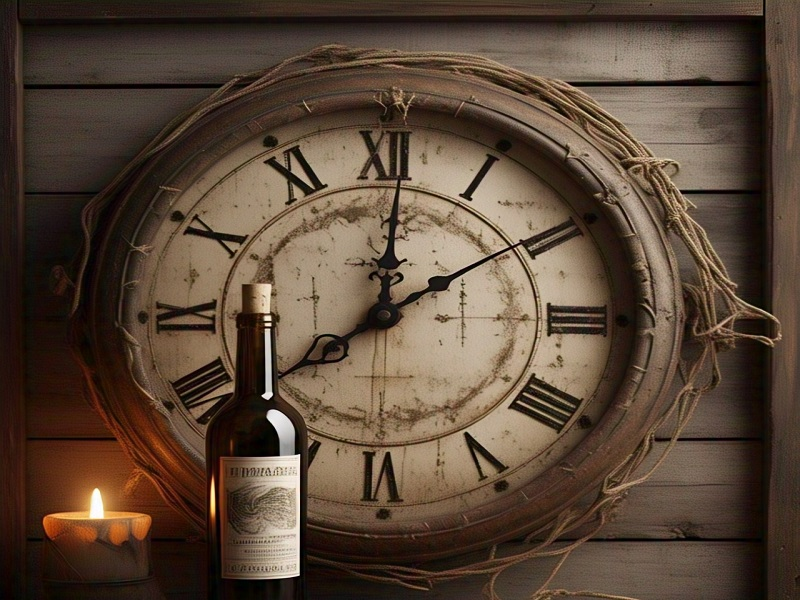

## **Vinho e previsão de demanda**

#### O **vinho** é uma bebida milenar apreciada em diversas culturas ao longo da história, não apenas pelo seu sabor e valor social, mas também por seus potenciais benefícios à saúde quando consumido com moderação. O que queremos verificar neste projeto é se podemos definir uma **previsão de vendas por valores** para uma **empresa fictícia**, e com isso, aperfeiçoar itens do processo, como por exemplo, **orçamento, gestão do estoque, mercado, público alvo, precificação**, para citar alguns.

#### Para tal, utilizaremos a biblioteca **Prophet**, desenvolvida pelo **Facebook**, extremamente robusta e que de maneira simplificada nos entrega o que de fato interessa numa **série temporal**, que é verificar se a série é **estacionária ou não**, ou seja, se **média, variância e covariância** são constantes ao longo do tempo.

#### Vamos compreender visualmente a **constância** de uma **série estacionária**:

<center>
<img src="https://cdn.analyticsvidhya.com/wp-content/uploads/2018/09/ns5-e1536673990684.png" width="50%"></center>

#### No primeiro gráfico acima, há uma **tendência de alta**. Ou seja, a **média está aumentando conforme o tempo**.

#### No segundo, apesar de não haver uma variação na tendência, a **variância (não constante)** está **interferindo** na sua amplitude. Percebe-se uma **irregularidade** nos dados.

#### Já o terceiro gráfico mostra o comportamento típico de quando a **covariância** varia em função do tempo. Também é nítida sua **irregularidade**.

#### - **Série estacionária**

#### Uma série com **média, variância e covariância constantes** seria parecida com o gráfico abaixo.

<center><img src="https://cdn.analyticsvidhya.com/wp-content/uploads/2018/09/ns6-e1536674898419.png" width="20%"></center>

#### Mas como verificar se uma **série é estacionária?**

* **Verificando os gráficos -** Em muitos casos, durante a análise exploratória poderemos identificar visualmente se uma série é estacionária ou não.

* **Observando o resumo estatístico -** Podemos gerar um resumo com as principais informações estatísticas da série temporal, e verificar se há algum indício da estacionaridade.

* **Realizando testes estatísticos -** São testes que possuem a capacidade de nos dizer se uma série temporal é estacionária ou não. Um dos principais é o teste ***Augmented Dickey Fuller (ADF)***, suas hipóteses nula e alternativa são:

- * A **Hipótese Nula ($H_0$)** do teste é que a série temporal **não é estacionária**. Ou seja, possui algum tipo de dependência em relação ao tempo.
- * A **Hipótese Alternativa ($H_1$) rejeita a hipótese nula**, ou seja, de que a série temporal é estacionária.

## **Prophet**

#### Sobre o algoritmo, ele precisa de um tipo muito específico de dataframe para funcionar.

* Para a linha do tempo no eixo **x**, uma data em uma coluna chamada **`ds`**.
* Para os valores no eixo **y**, os próprios valores em uma coluna chamada **`y`**.

In [ ]:
# 1 - Importando as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = "svg"
plt.rcParams["font.family"] = "sans-serif"
import seaborn as sns
from prophet import Prophet
from statsmodels.tsa.stattools import adfuller
import logging
logging.getLogger('prophet').setLevel(logging.WARNING)

In [ ]:
# 2 - Acessando e visualizando os dados
arquivo = "https://raw.githubusercontent.com/wallacecarlis/arquivos_ml/refs/heads/main/time_series_wine.csv"
df = pd.read_csv(arquivo)
print(df.shape)
df.head()

(1096, 2)


,ds,y
0,2018-01-01,43432
1,2018-01-02,43181
2,2018-01-03,43298
3,2018-01-04,42216
4,2018-01-05,42001


#### Como verificado acima, nossa base possui apenas 1096 linhas e 2 colunas. Podemos observar o **resumo estatístico** e tentar compreender como os valores estão dispostos na coluna **y** através de **mínimo, máximo, desvio padrão, média, mediana, primeiro e terceiro quartis**, além da contagem total dos valores.

In [ ]:
# 3 - Observando o resumo estatístico
df.y.describe()

,y
count,1096.000000
mean,46370.205292
std,2136.352810
min,38322.000000
25%,44833.750000
50%,46327.000000
75%,47699.500000
max,52901.000000


#### Uma vez que já acessamos a base de dados, podemos realizar o teste **ADF**:

> Normalmente, rejeitamos $H_0$ quando o *p-value* é **menor ou igual a um determinado nível de significância**. Normalmente, esse nível de significância é igual a 0.01 (1%), 0.05 (5%) ou até mesmo 0.1 (10%).

> Quanto **menor o *p-value***, mais evidências **contra a hipótese nula teremos**. Por exemplo, caso seja usado $\text{p-value} = 0.05$, rejeitamos a $H_0$ com um **nível de confiança de 95%**.

> Caso o valor do teste fique acima do *threshold*, **falharemos em rejeitar a hipótese nula**. Contudo, isso **não significa que $H_0$ é verdadeira**. Significa apenas que o experimento **não encontrou evidências para rejeitá-la**.

In [ ]:
# 4 - Definindo o valor de X e aplicando o teste ADF
X = df.y
adf = adfuller(X)
print("Augmented Dickey–Fuller")
print(f"Teste estatístico: {adf[0]:.4f}")
print(f"P Value: {adf[1]:.10f}")
print("Valores críticos para os nívels de significância:")
for key, value in adf[4].items():
	print(f"{key}: {value:.4f}")

Augmented Dickey–Fuller
Teste estatístico: -2.3601
P Value: 0.1533303754
Valores críticos para os nívels de significância:
1%: -3.4365
5%: -2.8642
10%: -2.5682


## Tamanho das Previsões x Nível de Confiança

#### Ao lidarmos com previsões em séries temporais precisamos ter em mente que quanto **maior o período** de nossas previsões, **menor confiança** teremos nos resultados. Para nosso projeto faremos previsões para um período de **30 dias**.

In [ ]:
# 5 - Definindo a previsão para 30 dias
prediction_size = 30
train_df = df[:-prediction_size]

#### Com o **conjunto de teste** definido, vamos instanciar e treinar nosso modelo, para fazer nossas previsões.

In [ ]:
# 6 - Instanciando, treinando o modelo e fazendo as previsões
model = Prophet()
model.fit(train_df)
future = model.make_future_dataframe(periods = prediction_size)
forecast = model.predict(future)
forecast.head()

DEBUG:cmdstanpy:input tempfile: /tmp/tmp32oahe0k/2znlghnd.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp32oahe0k/fk2kuji4.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=66526', 'data', 'file=/tmp/tmp32oahe0k/2znlghnd.json', 'init=/tmp/tmp32oahe0k/fk2kuji4.json', 'output', 'file=/tmp/tmp32oahe0k/prophet_modelesev2y2x/prophet_model-20251014203516.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
20:35:16 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
20:35:16 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2018-01-01,45499.039179,40903.909050,43940.907793,45499.039179,45499.039179,-3083.562908,-3083.562908,-3083.562908,-899.856816,-899.856816,-899.856816,-2183.706092,-2183.706092,-2183.706092,0.0,0.0,0.0,42415.476271
1,2018-01-02,45498.081259,41168.765634,44158.499210,45498.081259,45498.081259,-2800.707332,-2800.707332,-2800.707332,-616.589827,-616.589827,-616.589827,-2184.117505,-2184.117505,-2184.117505,0.0,0.0,0.0,42697.373927
2,2018-01-03,45497.123338,41383.792235,44619.539528,45497.123338,45497.123338,-2461.477525,-2461.477525,-2461.477525,-275.759820,-275.759820,-275.759820,-2185.717704,-2185.717704,-2185.717704,0.0,0.0,0.0,43035.645813
3,2018-01-04,45496.165418,41824.697179,45227.265470,45496.165418,45496.165418,-1982.107934,-1982.107934,-1982.107934,206.207569,206.207569,206.207569,-2188.315503,-2188.315503,-2188.315503,0.0,0.0,0.0,43514.057483
4,2018-01-05,45495.207497,42507.606878,45679.261752,45495.207497,45495.207497,-1340.649767,-1340.649767,-1340.649767,851.039599,851.039599,851.039599,-2191.689366,-2191.689366,-2191.689366,0.0,0.0,0.0,44154.557731


#### O **Prophet** traz em seu resultado de previsões diversas informações, entre elas, temos o **`yhat`**, que de fato são nossas **previsões**. Além disso temos também os limites inferiores e superiores, **`yhat_lower` e `yhat_upper`**, respectivamente, dentre outras informações que podem ser úteis para um **projeto real**.

### Visualizando as previsões:

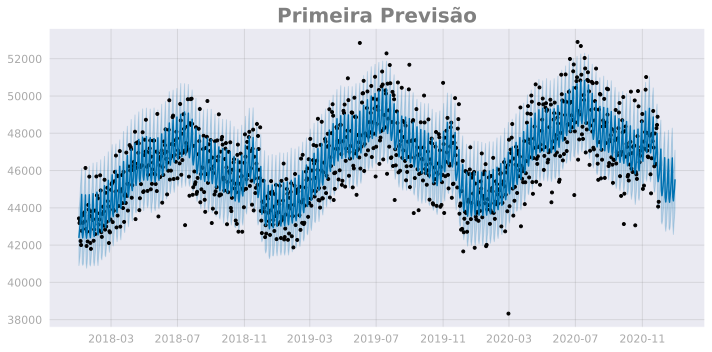

In [ ]:
# 7 - Visualizando a primeira previsão
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize = (10, 5), dpi = 300)
model.plot(forecast, ax = ax)
ax.set_title("Primeira Previsão", fontsize = 20, fontweight = "bold", color = "grey")
ax.set_ylabel("")
ax.set_xlabel("")
ax.tick_params(axis = "x", colors = "darkgrey", labelsize = 11)
ax.tick_params(axis = "y", colors = "darkgrey", labelsize = 11)
plt.tight_layout()

#### Além da previsão, podemos visualizar seus **componentes**.

Abaixo, podemos ver:

* Tendência Geral
* Tendência Semanal
* Tendência Anual


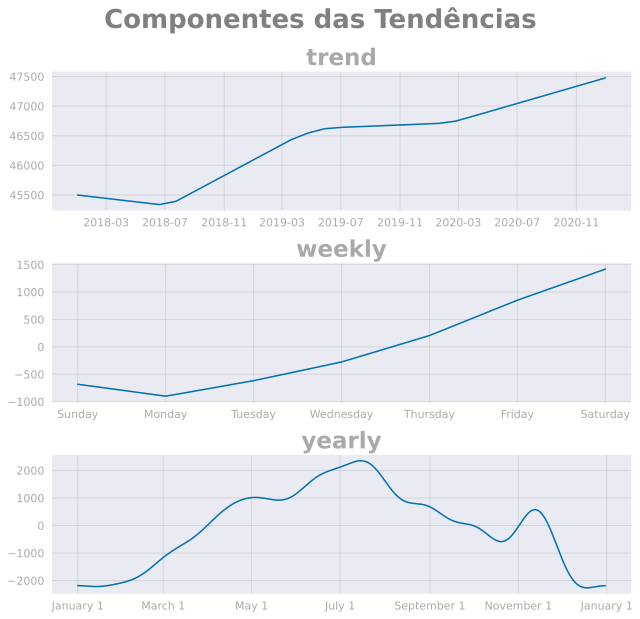

In [ ]:
# 8 - Visualizando os componentes
sns.set_style("darkgrid")
fig = model.plot_components(forecast)
axes = fig.get_axes()
for ax in axes:
    ax.tick_params(axis='x', colors='darkgrey', labelsize=11)
    ax.tick_params(axis='y', colors='darkgrey', labelsize=11)
    ax.set_title(ax.get_ylabel(), fontsize = 23, fontweight = "semibold",
                 color = "darkgrey")
    ax.set_ylabel("")
    ax.set_xlabel("")
fig.suptitle("Componentes das Tendências", fontsize = 26, fontweight = "bold",
             color = "grey", y = 0.95)
plt.tight_layout(rect = [0, 0, 1, 0.96])
plt.show()

#### Podemos confirmar se nossas previsões são realmente assertivas utilizando algumas métricas:

* Mean Absolute Percentage Error - Mostra quanto as nossas previsões diferem do valor real em porcentagem.
* Mean Absolute Error - Valor absoluto do nosso erro na previsão em relação à série real.

Abaixo temos uma função para calcular o MAPE e MAE da nossa série.

In [ ]:
# 9 - Criando função de comparação
def make_comparison_dataframe(historical, forecast):
  return forecast.set_index("ds")[["yhat", "yhat_lower", "yhat_upper"]].join(historical.set_index("ds"))

# Aplicando a função de comparação
cmp_df = make_comparison_dataframe(df, forecast)

# Criando função de cálculo de erro
def calculate_forecast_errors(df, prediction_size):
  df_copia = df.copy()
  df_copia['e'] = df_copia['y'] - df_copia['yhat']
  df_copia['p'] = 100 * df_copia['e'] / df_copia['y']
  predicted_part = df_copia[-prediction_size:]
  error_mean = lambda error_name: np.mean(np.abs(predicted_part[error_name]))
  return{"MAPE": error_mean("p"), "MAE": error_mean("e")}

# Verificando os erros MAPE e MAE
for err_name, err_value in calculate_forecast_errors(cmp_df, prediction_size).items():
  print(err_name, err_value)

MAPE nan
MAE nan


### **Série não estacionária**

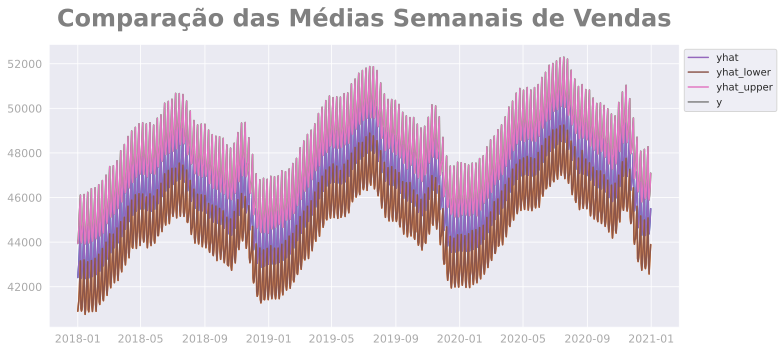

In [ ]:
# 10 - Visualizando as comparações
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize = (11,5), dpi = 300)
plt.plot(cmp_df["yhat"])
plt.plot(cmp_df["yhat_lower"])
plt.plot(cmp_df["yhat_upper"])
plt.plot(cmp_df["y"])
ax.set_title("Comparação das Médias Semanais de Vendas", color = "grey",
             fontsize = 24, fontweight = "bold", pad = 18)
ax.set_xlabel("")
ax.set_ylabel("")
ax.plot(cmp_df["yhat"], label = "yhat")
ax.plot(cmp_df["yhat_lower"], label = "yhat_lower")
ax.plot(cmp_df["yhat_upper"], label = "yhat_upper")
ax.plot(cmp_df["y"], label = "y")
ax.legend(bbox_to_anchor = (1,1))
ax.tick_params(axis='x', colors='darkgrey', labelsize=11)
ax.tick_params(axis='y', colors='darkgrey', labelsize=11)
plt.tight_layout()

#### Podemos verificar acima a **tendência de crescimento**, contudo, apesar dos resultados parecerem bons, na realidade estamos tendo um **erro absoluto grande** dentro do contexto que estamos lidando. Portanto, esse modelo servirá apenas de baseline. Agora, vamos transformar a **série em estacionária** e verificar o resultado.

### **Série estacionária**

> Como já mencionado, podemos transformar uma **série temporal em estacionária**, removendo a **tendência e a sazonalidade** que há nos dados originais.

> Uma bom começo é aplicar o **$log$ a fim de reduzirmos a magnitude** dos valores da série temporal. Na sequência, subtrairemos a **média móvel** de um determinado período em relação ao **$log$** da série temporal.

In [ ]:
# 11 - Definindo o índice
df.index = pd.to_datetime(df["ds"], format = "%Y-%m-%d")
df.drop("ds", axis = 1, inplace = True)
df.head()

,y
ds,
2018-01-01,43432
2018-01-02,43181
2018-01-03,43298
2018-01-04,42216
2018-01-05,42001


### **Média Móvel**

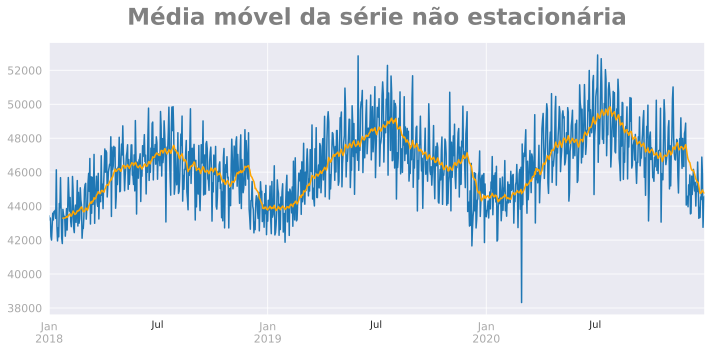

In [ ]:
# 12 - Criando uma média móvel
media_movel = df.rolling(24).mean()
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(10, 5), dpi = 300)
df.plot(ax = ax, legend = False)
media_movel.plot(ax = ax, color = "orange", legend = False)
ax.set_title("Média móvel da série não estacionária", color = "grey",
             fontsize = 23, fontweight = "bold", pad = 18)
ax.tick_params(axis='x', colors='darkgrey', labelsize=11)
ax.tick_params(axis='y', colors='darkgrey', labelsize=11)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()

### **Log** - alteração da magnitude, estabilização de variância, linearização de tendências exponenciais.

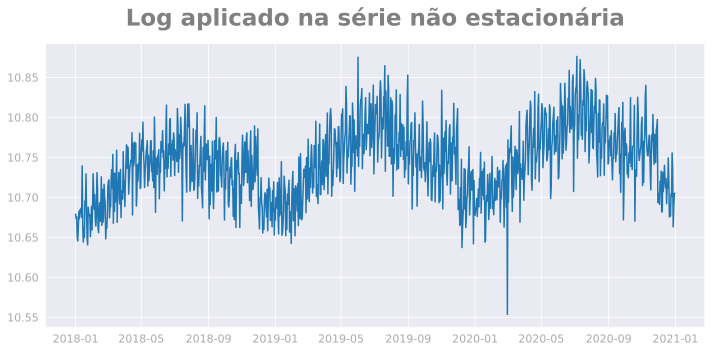

In [ ]:
# 13 - Aplicando o log
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize = (10, 5), dpi = 300)
ts_log = np.log(df)
plt.plot(ts_log)
ax.set_title("Log aplicado na série não estacionária", color = "grey",
             fontsize = 23, fontweight = "bold", pad = 18)
ax.tick_params(axis='x', colors='darkgrey', labelsize=11)
ax.tick_params(axis='y', colors='darkgrey', labelsize=11)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()

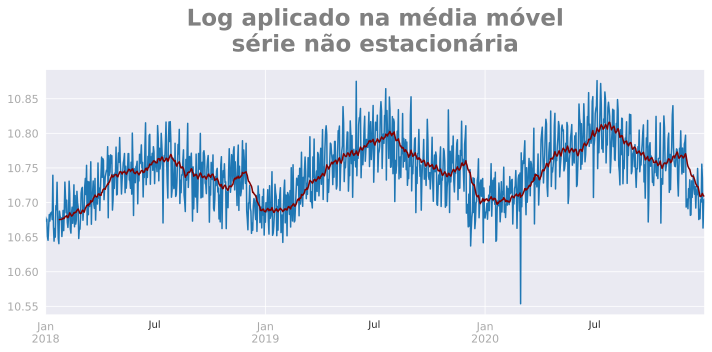

In [ ]:
# 14 - Aplicando o log na média móvel
df_log = np.log(df)
ma_log = df_log.rolling(24).mean()
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize = (10, 5))
df_log.plot(ax = ax, legend = False)
ma_log.plot(ax = ax, color = "maroon", legend = False)
ax.set_title("Log aplicado na média móvel\nsérie não estacionária", color = "grey",
             fontsize = 23, fontweight = "bold", pad = 18)
ax.tick_params(axis='x', colors='darkgrey', labelsize=11)
ax.tick_params(axis='y', colors='darkgrey', labelsize=11)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()

### **Log - Média Móvel** - Remoção de tendência e sazonalidade.

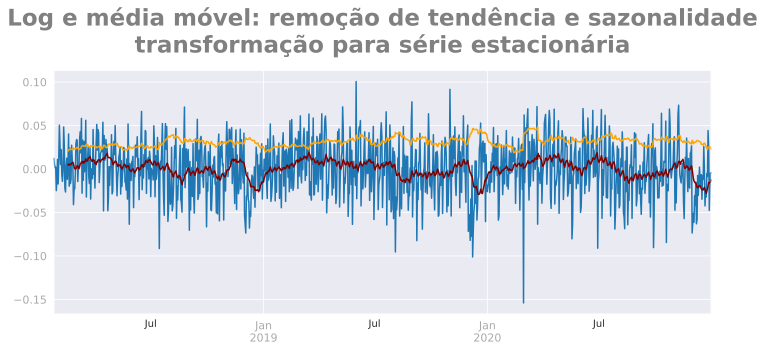

In [ ]:
# 15 - Subtraindo a média do log nos dados
df_sub  = (df_log - ma_log).dropna()
ma_sub  = df_sub.rolling(24).mean()
std_sub = df_sub.rolling(24).std()

sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize = (10, 5))
df_sub.plot(ax = ax, legend = False)
ma_sub.plot(ax = ax, color = "maroon", legend = False)
std_sub.plot(ax = ax, color = "orange", legend = False)

ax.set_title("Log e média móvel: remoção de tendência e sazonalidade\ntransformação para série estacionária",
             color = "grey", fontsize = 23, fontweight = "bold", pad = 18)
ax.tick_params(axis='x', colors='darkgrey', labelsize=11)
ax.tick_params(axis='y', colors='darkgrey', labelsize=11)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()

### **Teste de ADF**

In [ ]:
# 16 - Testando o ADF na base estacionária
X_sub = df_sub.y.values

# Aplicando o ADF e verificando os resultados
adf_sub = adfuller(X_sub)
print("Augmented Dickey–Fuller")
print(f"Teste estatístico: {adf_sub[0]:.4f}")
print(f"P Value: {adf_sub[1]:.10f}")
print("Valores críticos para os níveis de significância estacionária:")
for key, value in adf_sub[4].items():
	print(f"{key}: {value:.4f}")

Augmented Dickey–Fuller
Teste estatístico: -5.6436
P Value: 0.0000010231
Valores críticos para os níveis de significância estacionária:
1%: -3.4366
5%: -2.8643
10%: -2.5682


#### Agora temos uma comprovação com **nível de confiança** bem mais alto para considerar a nossa **série estacionária**. Contudo, existe outra técnica que podemos utilizar para potencializar esses resultados que é a **diferenciação**. No caso, basta calcularmos a **diferença** entre duas observações possíveis. Isso possibilitará melhorar o desempenho no ADF.

$$value(t) = observation(t) - observation(t -1)$$

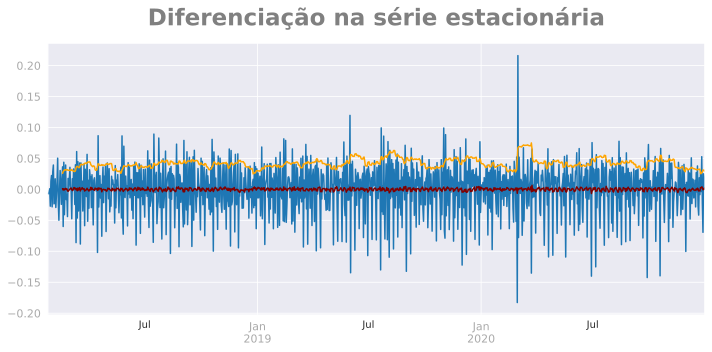

In [ ]:
# 17 - Aplicando a diferenciação
df_diff = df_sub.diff(1)
ma_diff = df_diff.rolling(24).mean()
std_diff = df_diff.rolling(24).std()

sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize = (10, 5), dpi = 300)
df_diff.plot(ax = ax, legend = False)
ma_diff.plot(ax = ax, color = 'maroon', legend = False)
std_diff.plot(ax = ax, color = 'orange', legend = False)
ax.set_title("Diferenciação na série estacionária",
             color = "grey", fontsize = 23, fontweight = "bold", pad = 18)
ax.tick_params(axis='x', colors='darkgrey', labelsize=11)
ax.tick_params(axis='y', colors='darkgrey', labelsize=11)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()

In [ ]:
# 18 - Extraindo os valores para a diferenciação
X_diff = df_diff.y.dropna().values

# Aplicando o ADF e verificando os resultados
adf_diff = adfuller(X_diff)
print("Augmented Dickey–Fuller")
print(f"Teste estatístico: {adf_diff[0]:.4f}")
print(f"P Value: {adf_diff[1]:.10f}")
print("Valores críticos para os níveis de significância da diferenciação:")
for key, value in adf_diff[4].items():
	print(f'{key}: {value:.4f}')

Augmented Dickey–Fuller
Teste estatístico: -11.3037
P Value: 0.0000000000
Valores críticos para os níveis de significância da diferenciação:
1%: -3.4366
5%: -2.8643
10%: -2.5682


#### Uma vez que compreendemos a diferença entre as **séries estacionárias e não estacionárias**, vamos executar o modelo sobre a base transformada pelo **log**.

In [ ]:
# 19 - Instanciando o modelo para a base log
df_log.reset_index(inplace = True)
prediction_size = 30
train_df = df_log[:-prediction_size]
model_log = Prophet()
model_log.fit(train_df)
future = model_log.make_future_dataframe(periods = prediction_size)
forecast = model_log.predict(future)
forecast.head()

DEBUG:cmdstanpy:input tempfile: /tmp/tmp32oahe0k/d8kn0d4c.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp32oahe0k/cbdwf9r_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=12693', 'data', 'file=/tmp/tmp32oahe0k/d8kn0d4c.json', 'init=/tmp/tmp32oahe0k/cbdwf9r_.json', 'output', 'file=/tmp/tmp32oahe0k/prophet_model1wig9ws7/prophet_model-20251014203521.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
20:35:21 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
20:35:21 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2018-01-01,10.727446,10.626160,10.694849,10.727446,10.727446,-0.068235,-0.068235,-0.068235,-0.019148,-0.019148,-0.019148,-0.049088,-0.049088,-0.049088,0.0,0.0,0.0,10.659210
1,2018-01-02,10.727406,10.632461,10.699572,10.727406,10.727406,-0.062152,-0.062152,-0.062152,-0.012997,-0.012997,-0.012997,-0.049155,-0.049155,-0.049155,0.0,0.0,0.0,10.665254
2,2018-01-03,10.727365,10.640078,10.706289,10.727365,10.727365,-0.054845,-0.054845,-0.054845,-0.005593,-0.005593,-0.005593,-0.049252,-0.049252,-0.049252,0.0,0.0,0.0,10.672520
3,2018-01-04,10.727325,10.650176,10.717722,10.727325,10.727325,-0.044589,-0.044589,-0.044589,0.004785,0.004785,0.004785,-0.049374,-0.049374,-0.049374,0.0,0.0,0.0,10.682736
4,2018-01-05,10.727285,10.660826,10.730163,10.727285,10.727285,-0.031244,-0.031244,-0.031244,0.018271,0.018271,0.018271,-0.049515,-0.049515,-0.049515,0.0,0.0,0.0,10.696041


### Visualizando as previsões

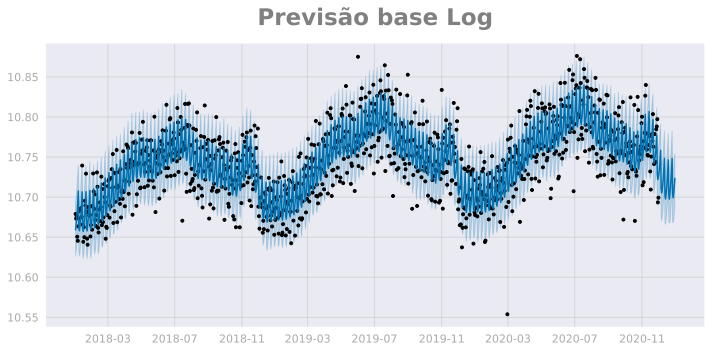

In [ ]:
# 20 - Visualizando as previsões
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize = (10, 5), dpi = 300)
model_log.plot(forecast, ax = ax)
ax.set_title("Previsão base Log", fontsize = 23, fontweight = "bold",
             color = "grey", pad = 18)
ax.set_ylabel("")
ax.set_xlabel("")
ax.tick_params(axis = "x", colors = "darkgrey", labelsize = 11)
ax.tick_params(axis = "y", colors = "darkgrey", labelsize = 11)
plt.tight_layout()

### Visualizando os componentes - **Base Log**

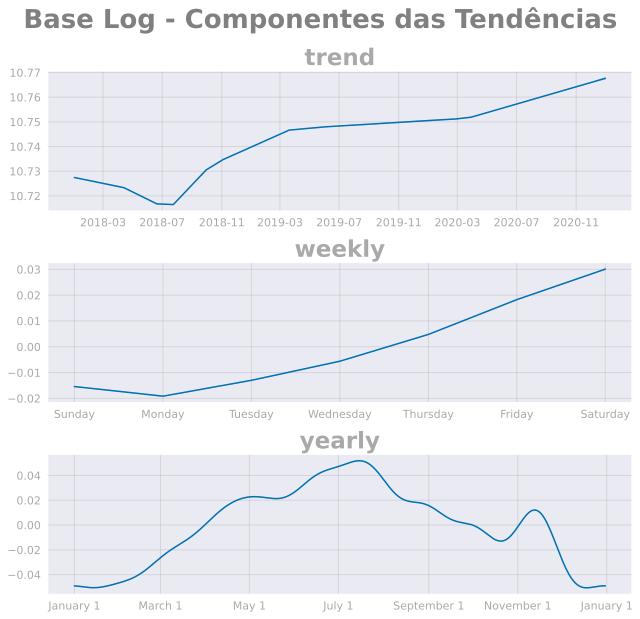

In [ ]:
# 21 - Visualizando os componentes
sns.set_style("darkgrid")
fig = model_log.plot_components(forecast)
axes = fig.get_axes()
for ax in axes:
    ax.tick_params(axis='x', colors='darkgrey', labelsize=11)
    ax.tick_params(axis='y', colors='darkgrey', labelsize=11)
    ax.set_title(ax.get_ylabel(), fontsize = 23, fontweight = "semibold",
                 color = "darkgrey")
    ax.set_ylabel("")
    ax.set_xlabel("")
fig.suptitle("Base Log - Componentes das Tendências", fontsize = 26,
             fontweight = "bold", color = "grey", y = 0.95)
plt.tight_layout(rect = [0, 0, 1, 0.96])

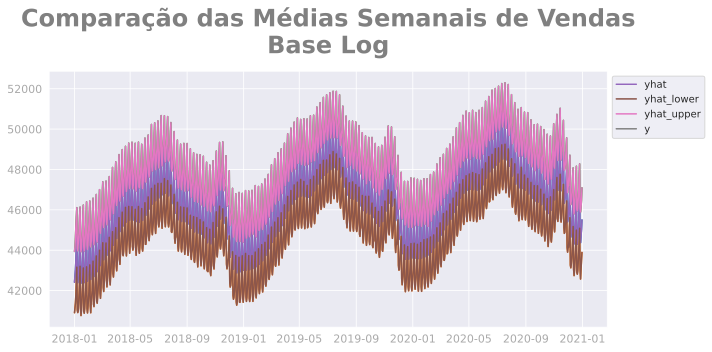

In [ ]:
# 22 - Visualizando os resultados
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize = (10, 5), dpi = 300)
plt.plot(cmp_df['yhat'])
plt.plot(cmp_df['yhat_lower'])
plt.plot(cmp_df['yhat_upper'])
plt.plot(cmp_df['y'])
ax.set_title("Comparação das Médias Semanais de Vendas\nBase Log", color = "grey",
             fontsize = 24, fontweight = "bold", pad = 18)
ax.set_xlabel("")
ax.set_ylabel("")
ax.plot(cmp_df['yhat'], label='yhat')
ax.plot(cmp_df['yhat_lower'], label='yhat_lower')
ax.plot(cmp_df['yhat_upper'], label='yhat_upper')
ax.plot(cmp_df['y'], label='y')
ax.legend(bbox_to_anchor = (1,1))
ax.tick_params(axis='x', colors='darkgrey', labelsize=11)
ax.tick_params(axis='y', colors='darkgrey', labelsize=11)
plt.tight_layout()

In [ ]:
# 23 - Aplicando as funções na base Log

# Aplicando a função de comparação na base log
cmp_df = make_comparison_dataframe(df_log, forecast)

# Verificando os resultados de MAPE e MAE na base log
for err_name, err_value in calculate_forecast_errors(cmp_df, prediction_size).items():
  print(err_name, err_value)

MAPE 0.20146121464112438
MAE 0.02156347466883067


#### Temos agora um resultado **bem eficiente** com um erro **significativamente baixo**. Entretanto, ainda será necessário retornar à escala dos valores configurados originalmente. No caso, sairemos de **log** para valores **exponenciais**.

#### Nossa base de dados **final** terá as colunas:

* Data (`ds`)
* Previsão do Prophet (`yhat`)
* Valor Gasto Real (`Amount_Spent`)
* Valor Gasto Previsto na escala correta (`Amount_Spent_Pred`)

In [ ]:
# 24 - Criando uma base de dados final
df_final = forecast[['ds', 'yhat']]
df_final = df_final.copy()
df_final['Amount_Spent_Log'] = df_log['y']
df_final['Valor_Gasto_Real'] = np.exp(df_final['Amount_Spent_Log'].values)
df_final['Valor_Gasto_Previsto'] = np.exp(df_final['yhat'].values)
df_final.head()

,ds,yhat,Amount_Spent_Log,Valor_Gasto_Real,Valor_Gasto_Previsto
0,2018-01-01,10.659210,10.678952,43432.0,42582.999945
1,2018-01-02,10.665254,10.673156,43181.0,42841.118768
2,2018-01-03,10.672520,10.675862,43298.0,43153.570560
3,2018-01-04,10.682736,10.650555,42216.0,43596.665314
4,2018-01-05,10.696041,10.645449,42001.0,44180.606047


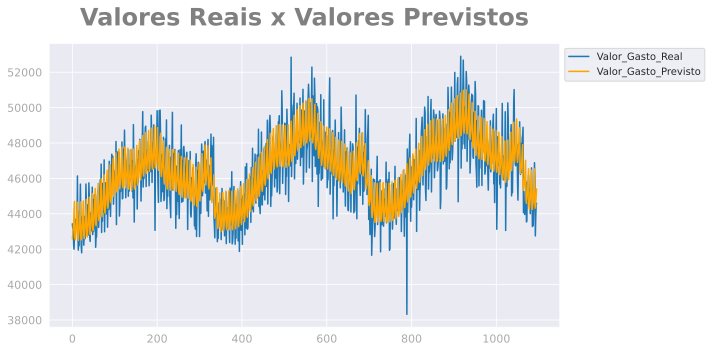

In [ ]:
# 25 - Gráfico: Valores Reais x Valores Previstos
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize = (10, 5), dpi = 300)
df_final['Valor_Gasto_Real'].plot(ax = ax, legend = ('Valor Gasto Real'))
df_final['Valor_Gasto_Previsto'].plot(ax=ax, color='orange')#, legend={'Predicted'})
ax.set_title("Valores Reais x Valores Previstos", color = "grey",
             fontsize = 24, fontweight = "bold", pad = 18)
ax.set_xlabel("")
ax.set_ylabel("")
ax.legend(bbox_to_anchor = (1, 1))
ax.tick_params(axis='x', colors='darkgrey', labelsize=11)
ax.tick_params(axis='y', colors='darkgrey', labelsize=11)
plt.tight_layout()

### Concluindo:

#### O time do **Facebook** acertou em cheio ao nos brindar com o algoritmo **Prophet**. Simples, direto e muito poderoso, dentre seus pontos positivos podemos destacar que ele:
- lida bem com sazonalidades múltiplas (diária, semanal, anual);
- lida naturalmente com dados faltantes e outliers;
- inclui feriados e eventos especiais;
- não requer estacionariedade.

#### Por outro lado, é menos flexível para modelos personalizados e pode não capturar tão bem relações complexas de autocorrelação. Mesmo assim, supriu muito bem nosso projeto.

#### Aplicamos log e média móvel para estabilizar a série. É bem verdade que após este passo, poderíamos usar não apenas o **Prophet** como **Arima** ou ainda **Sarima** de algoritmos para realizar as previsões de nossa série temporal. Vale, portanto, testes com estes modelos.

#### Ao final do nosso projeto pudemos verificar que o nosso modelo esteve um pouco mais próximo dos limites **superiores** do que dos **inferiores**, e no geral, em um bom ponto médio. Poderíamos também optar por previsões **mais otimistas** considerando o **`yhat_upper`**, ou ainda, para previsões mais pessimistas, o **`yhat_lower`**.

#### Como case de **previsão de demanda de vendas de vinho**, o projeto mostrou-se confiável servindo de base para aplicações reais.

#### Muito obrigado pela leitura. Caso tenha interesse em analisar outros projetos fique à vontade acessando diretamente meu [GitHub](https://github.com/wallacecarlis/data_science), [Medium](https://wallacecarlis.medium.com/), e meu [Site](https://www.wallacecarlis.com/). Todo feedback será bem-vindo, abs!